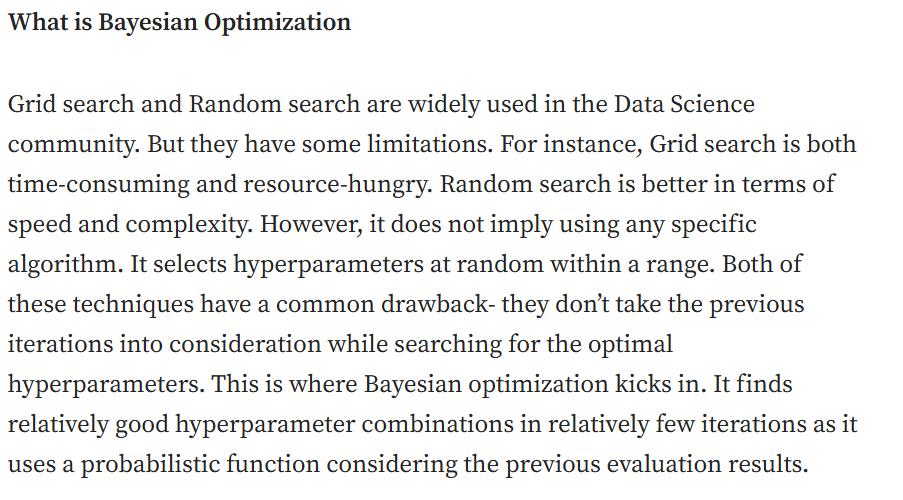

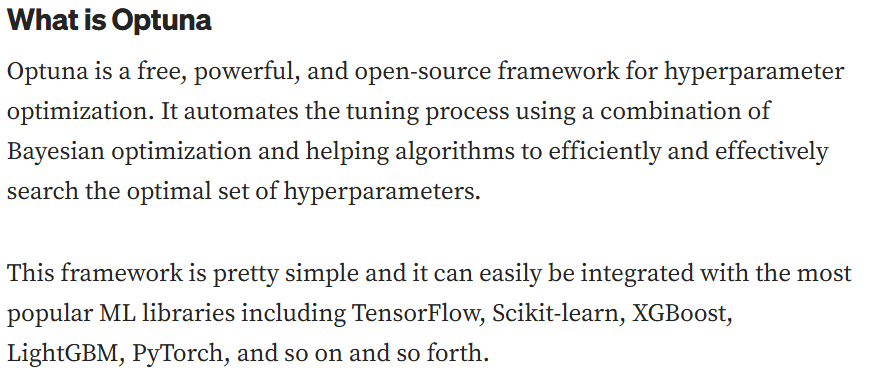

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 19.1 MB/s eta 0:00:00


In [4]:
import optuna
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

iris = load_iris()
X, y = iris.data, iris.target

# Define the objective function and suggest hyperparameters values
def objective(trial):
    svc_c = trial.suggest_loguniform('C', 1e-10, 1e10)
    svc_gamma = trial.suggest_loguniform('gamma', 1e-10, 1e10)
    clf = SVC(C=svc_c, gamma=svc_gamma)
    return cross_val_score(clf, X, y, n_jobs=-1, cv=3).mean()

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Print the best set of hyperparameters
print('Best hyperparameters: ', study.best_params)
# Print the corresponding performance
print('Best performance: ', study.best_value)

[I 2025-05-07 15:24:19,451] A new study created in memory with name: no-name-d01bcdc1-58e7-44f9-979b-4779077def28
<ipython-input-4-fe13da74db26>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  svc_c = trial.suggest_loguniform('C', 1e-10, 1e10)
<ipython-input-4-fe13da74db26>:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  svc_gamma = trial.suggest_loguniform('gamma', 1e-10, 1e10)
[I 2025-05-07 15:24:22,358] Trial 0 finished with value: 0.32666666666666666 and parameters: {'C': 16329.09193449536, 'gamma': 8252169381.211079}. Best is trial 0 with value: 0.32666666666666666.
<ipython-input-4-fe13da74db26>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0

Best hyperparameters:  {'C': 53.71644332061308, 'gamma': 0.005651140777772326}
Best performance:  0.9866666666666667


# **Optuna Hyperparameter Tuning: A Comprehensive Guide**

---

## 📘 Table of Contents

1. [Introduction to Hyperparameter Tuning](#introduction-to-hyperparameter-tuning)
2. [What is Optuna?](#what-is-optuna)
3. [Why Use Optuna?](#why-use-optuna)
4. [Core Concepts and Terminologies](#core-concepts-and-terminologies)
5. [Mathematical Foundations](#mathematical-foundations)
6. [Optimization Algorithms in Optuna](#optimization-algorithms-in-optuna)
7. [Pruning Strategies](#pruning-strategies)
8. [Working with Optuna – Step-by-Step Example](#working-with-optuna---step-by-step-example)
9. [Visualizations and Analysis](#visualizations-and-analysis)
10. [Advanced Features](#advanced-features)
11. [Comparison with Other Libraries](#comparison-with-other-libraries)
12. [Conclusion](#conclusion)

---

## 🔍 1. Introduction to Hyperparameter Tuning

Hyperparameters are configuration settings that control the learning process of a machine learning model. Examples include:

- Learning rate
- Number of hidden layers in a neural network
- Regularization strength (e.g., L1, L2)
- Batch size
- Tree depth in gradient boosting models

Unlike model parameters (which are learned during training), hyperparameters must be set **before** training begins.

The goal of **hyperparameter tuning** is to find the best combination of these values that leads to optimal model performance.

---

## 💡 2. What is Optuna?

**Optuna** is an open-source Python library designed for **automated hyperparameter optimization**. It provides a flexible and efficient framework to search for the best hyperparameters using various strategies like Bayesian Optimization, Evolutionary Algorithms, and more.

It supports:
- **Asynchronous evaluation**
- **Parallel execution**
- **Early stopping (pruning)**
- **Multi-objective optimization**

Optuna's API is clean and user-friendly, making it ideal for both beginners and advanced users.

---

## ✅ 3. Why Use Optuna?

| Feature | Description |
|--------|-------------|
| **Efficiency** | Uses smart sampling methods to reduce the number of trials needed |
| **Flexibility** | Supports custom objective functions, constraints, and conditions |
| **Scalability** | Can run on single machines or distributed environments |
| **Pruning Support** | Stops unpromising trials early to save time and resources |
| **Visualization Tools** | Built-in tools to visualize progress, parameter importance, and trade-offs |
| **Integration** | Works well with major ML/DL libraries like TensorFlow, PyTorch, XGBoost, Scikit-learn |

---

## 📚 4. Core Concepts and Terminologies

### 🔁 Study
A `Study` is the main object in Optuna that manages the entire optimization process. It stores all trial results, tracks the best parameters, and defines whether the goal is to **minimize** or **maximize** the objective function.

```python
study = optuna.create_study(direction="minimize")
```

### 🧪 Trial
Each `Trial` represents a single run of your objective function with a specific set of hyperparameters suggested by the sampler.

```python
def objective(trial):
    x = trial.suggest_float("x", -10, 10)
    return (x - 2) ** 2
```

### 🔍 Sampler
A `Sampler` decides which hyperparameters to try next based on previous results. The default is **Tree-structured Parzen Estimator (TPE)**.

```python
sampler = optuna.samplers.TPESampler()
study = optuna.create_study(sampler=sampler, direction="minimize")
```

### ⛔ Pruner
A `Pruner` stops unpromising trials early based on intermediate results (like validation loss after each epoch).

```python
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(pruner=pruner, direction="minimize")
```

### 🎯 Objective Function
This is the function you define to train and evaluate your model with a given set of hyperparameters.

```python
def objective(trial):
    # Define hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    num_layers = trial.suggest_int("num_layers", 1, 5)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])

    # Train and evaluate model
    score = train_model(lr, num_layers, activation)

    return score  # This is what we optimize
```

---

## 📐 5. Mathematical Foundations

### 🧠 Bayesian Optimization Overview

Bayesian Optimization is a sequential design strategy for global optimization of black-box functions that are expensive to evaluate.

#### Key Components:
1. **Surrogate Model**: Approximates the true objective function.
   - Commonly used: Gaussian Processes (GP), Tree-Structured Parzen Estimators (TPE)
2. **Acquisition Function**: Balances exploration vs exploitation to select the next point.

$$
x_{\text{next}} = \arg\max_x A(x)
$$

Where $ A(x) $ is the acquisition function.

---

### 🌳 Tree-Structured Parzen Estimator (TPE)

TPE is a powerful method used by Optuna as its default sampler. Instead of modeling the objective function directly, TPE models the probability distributions of good and bad hyperparameters separately.

#### Steps:
1. Split observed trials into two groups:
   - Good trials: Those with low loss (or high accuracy)
   - Bad trials: Those with high loss
2. Fit kernel density estimators (KDE) to both groups:
   - $ l(x) $: Likelihood of being a good trial
   - $ g(x) $: Likelihood of being a bad trial
3. The acquisition function becomes:

$$
A(x) = \frac{l(x)}{g(x)}
$$

We then sample from the region where this ratio is highest.

---

## 🧮 6. Optimization Algorithms in Optuna

| Sampler | Description | Best For |
|--------|-------------|----------|
| **TPESampler** | Tree-structured Parzen Estimator | General-purpose |
| **RandomSampler** | Randomly selects hyperparameters | Baseline comparison |
| **GridSampler** | Exhaustive grid search | Small spaces |
| **CmaEsSampler** | CMA-ES evolutionary algorithm | Continuous variables |
| **NSGAIISampler** | Multi-objective genetic algorithm | MOO problems |
| **BruteForceSampler** | Evaluates all possible combinations | Very small discrete spaces |

---

## ⏱️ 7. Pruning Strategies

Pruning helps stop unpromising trials early to save computational resources.

### 🧭 Successive Halving Algorithm (SHA)

1. Start with many configurations.
2. Evaluate them partially (e.g., after 1 epoch).
3. Keep only top performers.
4. Repeat until one remains.

### 🧨 Median Pruner (Default in Optuna)

Stops a trial if its intermediate value is worse than the median of previous trials at the same step.

```python
trial.report(value, step)
if trial.should_prune():
    raise optuna.exceptions.TrialPruned()
```

Other pruners include:
- **PercentilePruner**
- **PatientPruner**
- **HyperbandPruner**

---

## 🧩 8. Working with Optuna – Step-by-Step Example

```python
import optuna

def objective(trial):
    x = trial.suggest_float("x", -10, 10)
    return (x - 2) ** 2  # Minimize this function

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("Best parameters:", study.best_params)
print("Best value:", study.best_value)
```

---

## 📈 9. Visualizations and Analysis

Optuna offers rich visualization capabilities through the `optuna.visualization` module.

### 🔍 Optimization History

```python
optuna.visualization.plot_optimization_history(study).show()
```

### 📊 Parameter Importances

```python
optuna.visualization.plot_param_importances(study).show()
```

### 🗺️ Slice Plot

```python
optuna.visualization.plot_slice(study).show()
```

### 📍 Contour Plot

```python
optuna.visualization.plot_contour(study, params=["x", "y"]).show()
```

### 🧮 Pareto Front (for multi-objective)

```python
optuna.visualization.plot_pareto_front(study).show()
```

---

## 🚀 10. Advanced Features

### 🔄 Multi-Objective Optimization

You can optimize multiple metrics simultaneously:

```python
study = optuna.create_study(directions=["minimize", "maximize"])
```

### 📦 Distributed Execution

Use Redis or RDB backend to run across multiple machines:

```bash
redis-server
```

```python
storage = optuna.storages.RedisStorage("redis://localhost:6379/")
study = optuna.create_study(storage=storage, study_name="distributed-study")
```

### 🕒 Warm Start / Resume

Load previous studies and continue:

```python
study = optuna.load_study(study_name="example-study", storage="sqlite:///example.db")
study.optimize(objective, n_trials=50)
```

### 🧱 Constraints and Conditional Sampling

Add logic inside the objective function:

```python
if trial.suggest_categorical("use_dropout", [True, False]):
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
```

---

## 📊 11. Comparison with Other Libraries

| Library | Method | Strengths | Weaknesses |
|--------|--------|-----------|------------|
| **Optuna** | TPE, CMA-ES, SHA | Fast, easy to use, pruning support | Less mature for large-scale DL |
| **Hyperopt** | TPE, Random Search | Good for small problems | Not as user-friendly |
| **Scikit-optimize** | GP-based BO | Strong theoretical foundation | Slower than TPE |
| **Ray Tune** | Many algorithms | Great for scaling | Complex setup |
| **Keras Tuner** | Built for Keras | Easy integration | Limited flexibility |

---

## 🧠 12. Conclusion

Optuna is a powerful, modern tool for automated hyperparameter tuning that combines speed, flexibility, and scalability. Its intuitive interface allows developers to focus on building better models rather than manually tweaking hyperparameters.

By leveraging probabilistic models like TPE, along with pruning and parallelization, Optuna significantly reduces the time and effort required to find optimal configurations.

Whether you're working with classical ML models or deep learning architectures, Optuna offers a robust and extensible platform to improve your model's performance systematically.

---

## 📚 Further Reading

- [Official Optuna Documentation](https://optuna.readthedocs.io/)
- [Optuna GitHub Repository](https://github.com/optuna/optuna)
- [Optuna Examples Collection](https://github.com/optuna/optuna-examples)

---



# **Optuna TPE Algorithm Explained in Simple Steps (Minimalist Version)**

---

## 🔍 Step-by-Step: How Optuna's TPE Works

1. **Start with an Objective Function**  
   Define what you're optimizing (e.g., validation loss, accuracy).

2. **Run First Few Trials Randomly**  
   Try some random hyperparameter combinations to collect initial results.

3. **Separate Good vs Bad Results**  
   Split trials into:
   - Good (low loss / high score)
   - Bad (high loss / low score)

4. **Build Two Models (Distributions)**  
   - `l(x)` → model of where good results happen  
   - `g(x)` → model of where bad results happen

5. **Score New Points Using Ratio**  
   For each new candidate hyperparameter set:
   $$
   \text{score} = \frac{l(x)}{g(x)}
   $$
   High score = likely good point

6. **Pick Best Candidate as Next Trial**  
   Try the hyperparameters that scored highest.

7. **Repeat Until Done**  
   Add new result to history and repeat from Step 3.

---

## 🧠 Bonus: Handles Conditional Hyperparameters

TPE understands logic like:

```python
if trial.suggest_categorical("use_dropout", [True, False]):
    rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
```

It builds a **tree structure** to handle such conditions automatically.

---

## ✅ Why It's Smart

- Learns from past trials
- Focuses on promising areas
- Avoids repeating bad choices
- Automatically handles complex search spaces

---

## 🚀 TL;DR – TPE in 5 Lines

1. Try some hyperparameters.
2. See which ones work well.
3. Build models of good vs bad regions.
4. Pick next guess where good is much more likely than bad.
5. Repeat until best result found.

---

